# Clustering & Deteksi Outlier
## Mental Health Pelajar Indonesia — GSHS 2015

**Input:** `gshs2015_for_clustering.csv`  
**Baris:** 10.977 pelajar | **Fitur:** 22 (sudah ternormalisasi) | **Label validasi:** `target` (QN24)

**Algoritma:**
- K-Medoids (partition-based, robust terhadap outlier)
- Hierarchical Agglomerative Clustering (Ward linkage)
- DBSCAN (density-based, deteksi noise otomatis)

**Deteksi Outlier:** DBSCAN noise · LOF · Isolation Forest

---
### Daftar Isi
1. Import & Load Data
2. Eksplorasi Awal
3. Penentuan Jumlah Cluster Optimal (Elbow, Silhouette, DB, CH)
4. K-Medoids
5. Hierarchical Clustering
6. DBSCAN
7. Perbandingan Ketiga Algoritma
8. Interpretasi Profil Cluster
9. Deteksi Outlier
10. Visualisasi PCA & t-SNE
11. Kesimpulan & Export

---
## 1. Import & Load Data

In [2]:
# !pip install scikit-learn-extra scikit-learn matplotlib seaborn pandas numpy scipy
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn_extra.cluster import KMedoids
from sklearn.cluster import AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)
from sklearn.neighbors import LocalOutlierFactor, NearestNeighbors
from sklearn.ensemble import IsolationForest
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['axes.titlesize'] = 13
sns.set_style('whitegrid')
COLORS = sns.color_palette('tab10', 8)
RS = 42
np.random.seed(RS)
print('Library siap!')

Library siap!


In [3]:
df = pd.read_csv('gshs2015_for_clustering.csv')

LABEL_COL   = 'target'
feature_cols = [c for c in df.columns if c != LABEL_COL]
X      = df[feature_cols].values
y_true = df[LABEL_COL].values

print(f'Dataset   : {df.shape[0]:,} baris × {df.shape[1]} kolom')
print(f'Fitur     : {len(feature_cols)}')
print(f'Missing   : {df.isnull().sum().sum()}')
print(f'\nFitur:')
for i, c in enumerate(feature_cols, 1):
    print(f'  {i:2}. {c}')

Dataset   : 10,977 baris × 23 kolom
Fitur     : 22
Missing   : 0

Fitur:
   1. usia_norm
   2. kelas_norm
   3. bmi_norm
   4. kesepian_norm
   5. khawatir_insomnia_norm
   6. diserang_fisik_norm
   7. perkelahian_fisik_norm
   8. hari_dibully_norm
   9. hari_merokok_norm
  10. hari_minum_alkohol_norm
  11. frek_mabuk_norm
  12. mh_risk_score_norm
  13. behavior_risk_score_norm
  14. gender_bin
  15. jenjang_bin
  16. bmi_encoded
  17. flag_perokok_bin
  18. flag_alkohol_bin
  19. flag_narkoba_bin
  20. flag_dibully_bin
  21. flag_diserang_bin
  22. flag_aktif_fisik_bin


---
## 2. Eksplorasi Awal

In [4]:
# Statistik deskriptif
df[feature_cols].describe().T.round(3)

,count,mean,std,min,25%,50%,75%,max
usia_norm,10977.0,0.434,0.227,0.0,0.286,0.429,0.571,1.0
kelas_norm,10977.0,0.355,0.304,0.0,0.200,0.400,0.600,1.0
bmi_norm,10977.0,0.173,0.098,0.0,0.109,0.158,0.212,1.0
kesepian_norm,10977.0,0.278,0.266,0.0,0.000,0.250,0.500,1.0
khawatir_insomnia_norm,10977.0,0.252,0.260,0.0,0.000,0.250,0.500,1.0
diserang_fisik_norm,10977.0,0.087,0.162,0.0,0.000,0.000,0.143,1.0
perkelahian_fisik_norm,10977.0,0.061,0.147,0.0,0.000,0.000,0.000,1.0
hari_dibully_norm,10977.0,0.052,0.141,0.0,0.000,0.000,0.000,1.0
hari_merokok_norm,10977.0,0.040,0.155,0.0,0.000,0.000,0.000,1.0
hari_minum_alkohol_norm,10977.0,0.010,0.062,0.0,0.000,0.000,0.000,1.0


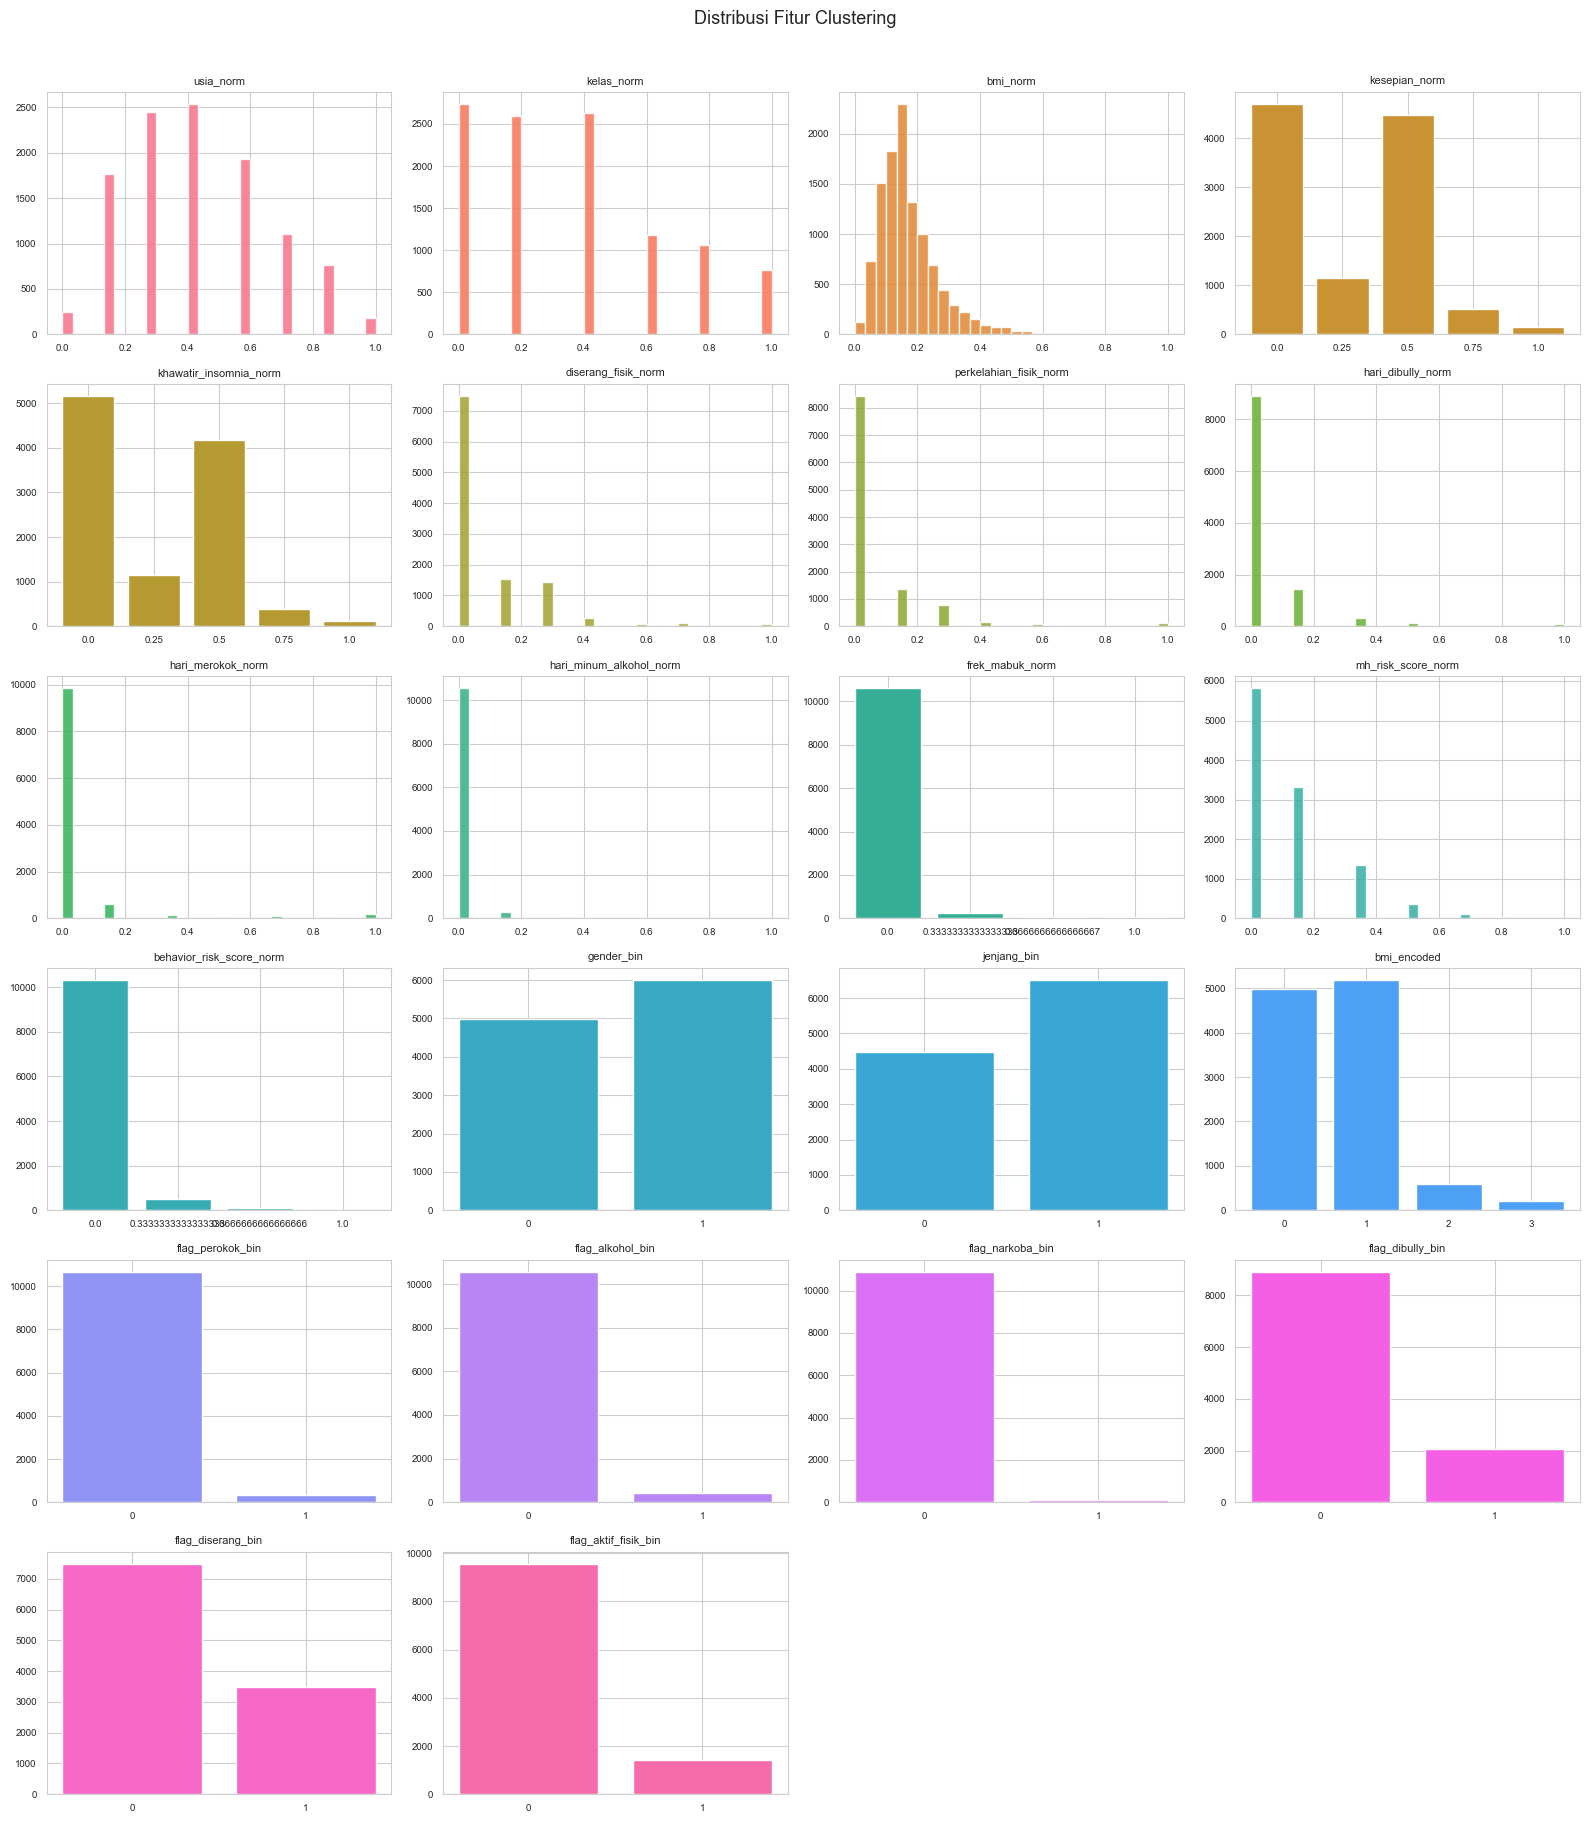

In [5]:
# Distribusi tiap fitur
n_cols_p = 4
n_rows_p = int(np.ceil(len(feature_cols) / n_cols_p))
fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(16, n_rows_p * 3))
axes = axes.flatten()
palette = sns.color_palette('husl', len(feature_cols))
for i, (col, color) in enumerate(zip(feature_cols, palette)):
    ax = axes[i]
    if df[col].nunique() <= 5:
        vc = df[col].value_counts().sort_index()
        ax.bar(vc.index.astype(str), vc.values, color=color, edgecolor='white')
    else:
        ax.hist(df[col], bins=30, color=color, edgecolor='white', alpha=0.85)
    ax.set_title(col, fontsize=8)
    ax.tick_params(labelsize=7)
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Distribusi Fitur Clustering', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

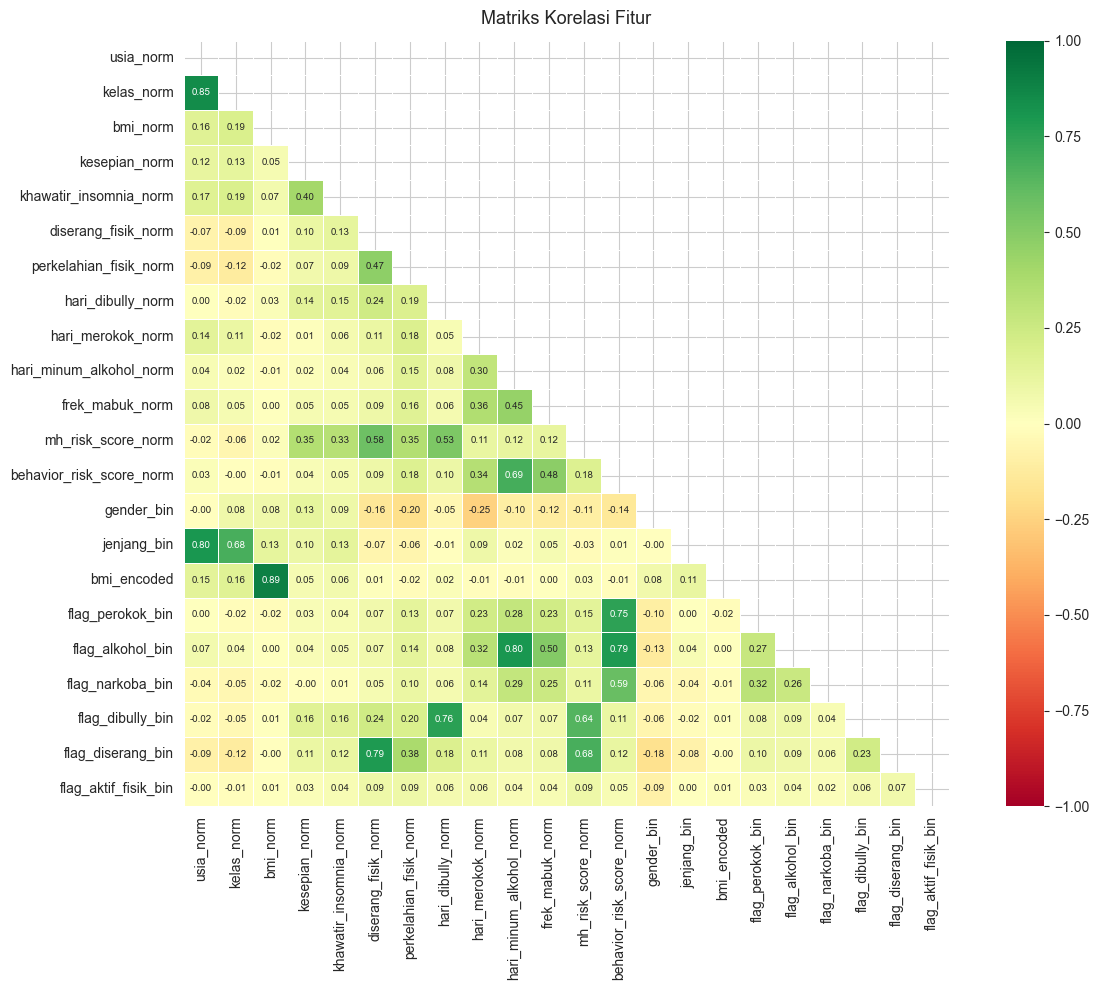

In [6]:
# Heatmap korelasi
fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(df[feature_cols].corr(), dtype=bool))
sns.heatmap(df[feature_cols].corr(), mask=mask, annot=True, fmt='.2f',
            cmap='RdYlGn', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.4, ax=ax, annot_kws={'size': 7})
ax.set_title('Matriks Korelasi Fitur', pad=12)
plt.tight_layout()
plt.show()

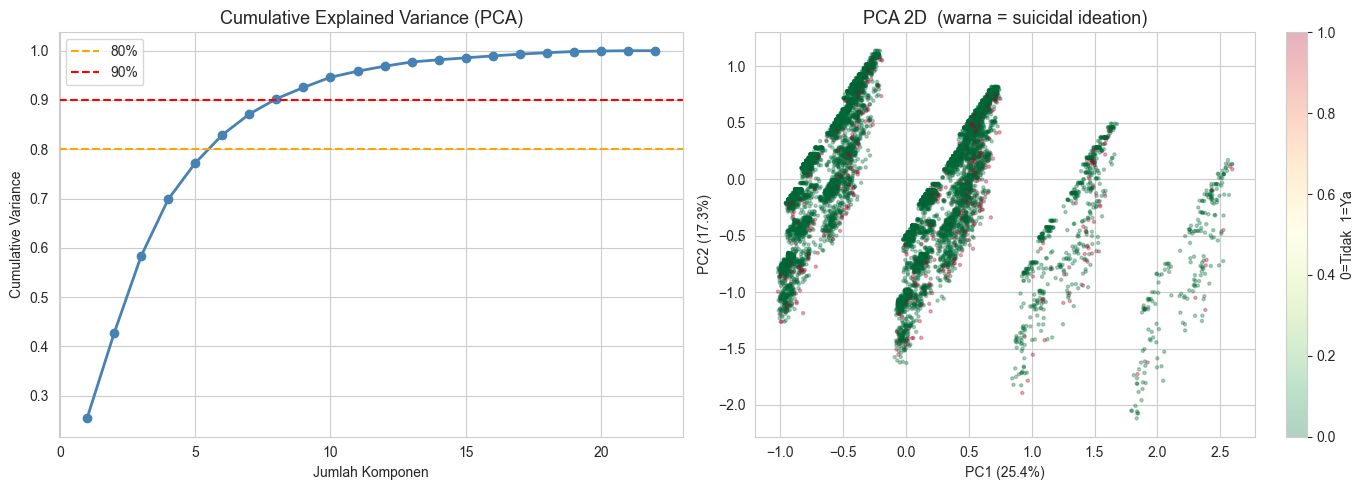

PC1+PC2 menjelaskan 42.6% variance


In [7]:
# PCA 2D eksplorasi awal
pca_full = PCA(random_state=RS).fit(X)
pca2     = PCA(n_components=2, random_state=RS)
X_pca    = pca2.fit_transform(X)
ev       = np.cumsum(pca_full.explained_variance_ratio_)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(range(1, len(ev)+1), ev, 'o-', color='steelblue', lw=2)
axes[0].axhline(0.80, color='orange', ls='--', label='80%')
axes[0].axhline(0.90, color='red',    ls='--', label='90%')
axes[0].set_title('Cumulative Explained Variance (PCA)')
axes[0].set_xlabel('Jumlah Komponen')
axes[0].set_ylabel('Cumulative Variance')
axes[0].legend()

sc = axes[1].scatter(X_pca[:,0], X_pca[:,1], c=y_true,
                     cmap='RdYlGn_r', alpha=0.3, s=5)
axes[1].set_title('PCA 2D  (warna = suicidal ideation)')
axes[1].set_xlabel(f'PC1 ({pca_full.explained_variance_ratio_[0]*100:.1f}%)')
axes[1].set_ylabel(f'PC2 ({pca_full.explained_variance_ratio_[1]*100:.1f}%)')
plt.colorbar(sc, ax=axes[1], label='0=Tidak  1=Ya')
plt.tight_layout()
plt.show()
print(f'PC1+PC2 menjelaskan {ev[1]*100:.1f}% variance')

---
## 3. Penentuan Jumlah Cluster Optimal

In [8]:
K_RANGE = range(2, 9)
inertia_list, sil_list, db_list, ch_list = [], [], [], {}

print(f'{"k":>3}  {"Inertia":>10}  {"Silhouette":>12}  {"Davies-Bouldin":>15}  {"Calinski-H":>12}')
print('-' * 60)
for k in K_RANGE:
    km     = KMedoids(n_clusters=k, random_state=RS, max_iter=300)
    labels = km.fit_predict(X)
    inertia_list.append(km.inertia_)
    sil    = silhouette_score(X, labels)
    db     = davies_bouldin_score(X, labels)
    ch     = calinski_harabasz_score(X, labels)
    sil_list.append(sil); db_list.append(db); ch_list[k] = ch
    print(f'{k:>3}  {km.inertia_:>10.2f}  {sil:>12.4f}  {db:>15.4f}  {ch:>12.1f}')

  k     Inertia    Silhouette   Davies-Bouldin    Calinski-H
------------------------------------------------------------
  2    14929.37        0.1819           2.0118        2481.7
  3    13615.70        0.1811           1.7744        2171.8
  4    12720.13        0.1930           1.8458        1941.5
  5    12682.71        0.1642           3.1446        1473.8
  6    12557.50        0.1635           2.8085        1231.4
  7    12532.74        0.1634           3.0448        1036.8
  8    12388.11        0.1314           3.4148         941.8


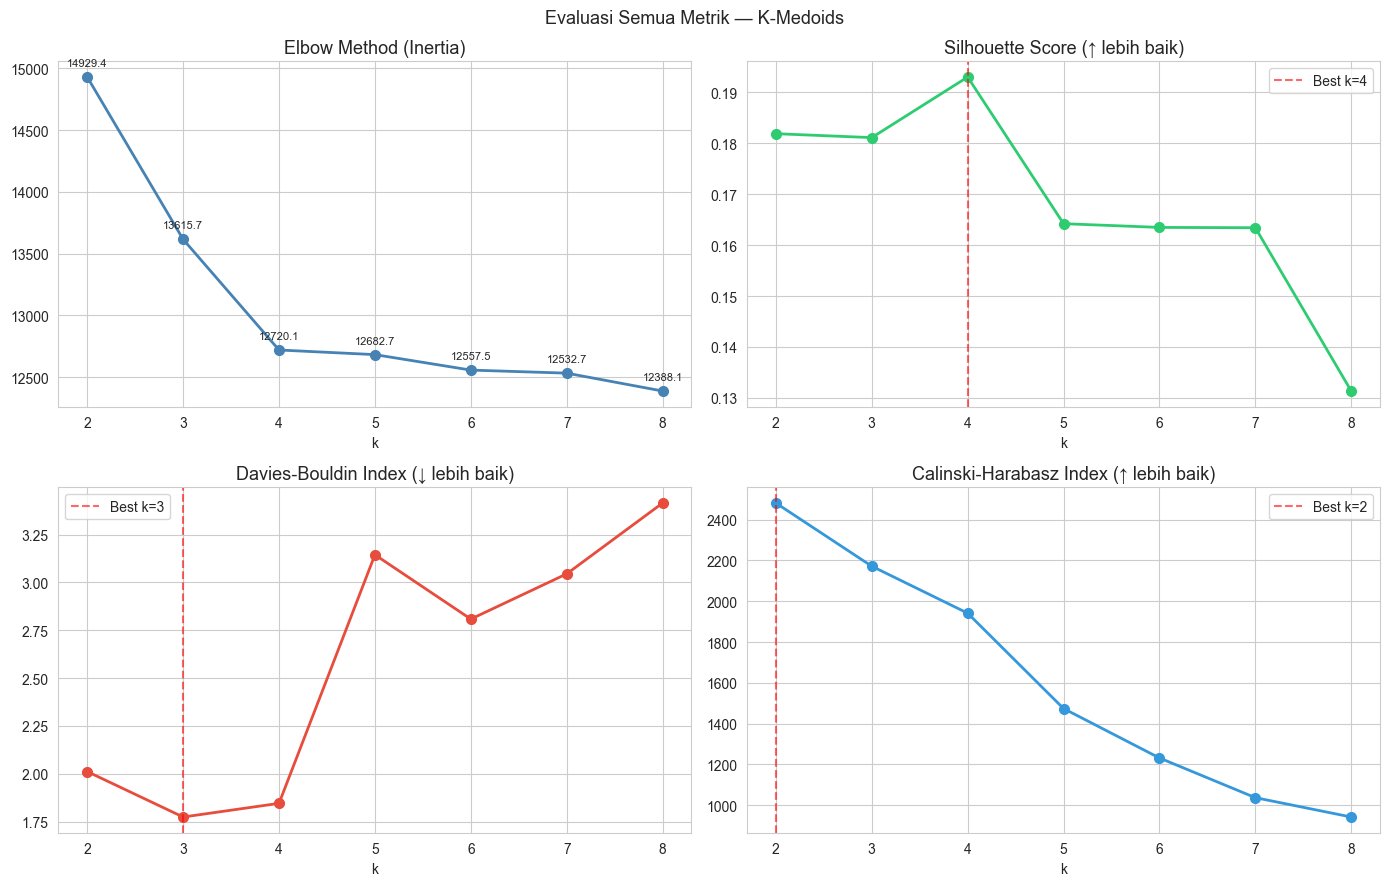

Rekomendasi k: Silhouette=4, DB=3, CH=2


In [9]:
k_list = list(K_RANGE)
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Elbow
axes[0,0].plot(k_list, inertia_list, 'o-', color='steelblue', lw=2, ms=7)
axes[0,0].set_title('Elbow Method (Inertia)')
axes[0,0].set_xlabel('k'); axes[0,0].set_xticks(k_list)
for k, v in zip(k_list, inertia_list):
    axes[0,0].annotate(f'{v:.1f}', (k, v), xytext=(0,8),
                       textcoords='offset points', ha='center', fontsize=8)

# Silhouette
best_k_sil = k_list[np.argmax(sil_list)]
axes[0,1].plot(k_list, sil_list, 'o-', color='#2ECC71', lw=2, ms=7)
axes[0,1].axvline(best_k_sil, color='red', ls='--', alpha=0.6, label=f'Best k={best_k_sil}')
axes[0,1].set_title('Silhouette Score (↑ lebih baik)')
axes[0,1].set_xlabel('k'); axes[0,1].set_xticks(k_list); axes[0,1].legend()

# Davies-Bouldin
best_k_db = k_list[np.argmin(db_list)]
axes[1,0].plot(k_list, db_list, 'o-', color='#E74C3C', lw=2, ms=7)
axes[1,0].axvline(best_k_db, color='red', ls='--', alpha=0.6, label=f'Best k={best_k_db}')
axes[1,0].set_title('Davies-Bouldin Index (↓ lebih baik)')
axes[1,0].set_xlabel('k'); axes[1,0].set_xticks(k_list); axes[1,0].legend()

# Calinski-Harabasz
ch_vals   = [ch_list[k] for k in k_list]
best_k_ch = k_list[np.argmax(ch_vals)]
axes[1,1].plot(k_list, ch_vals, 'o-', color='#3498DB', lw=2, ms=7)
axes[1,1].axvline(best_k_ch, color='red', ls='--', alpha=0.6, label=f'Best k={best_k_ch}')
axes[1,1].set_title('Calinski-Harabasz Index (↑ lebih baik)')
axes[1,1].set_xlabel('k'); axes[1,1].set_xticks(k_list); axes[1,1].legend()

plt.suptitle('Evaluasi Semua Metrik — K-Medoids', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Rekomendasi k: Silhouette={best_k_sil}, DB={best_k_db}, CH={best_k_ch}')

---
## 4. K-Medoids

In [10]:
BEST_K = 3   # ← sesuaikan berdasarkan hasil evaluasi di atas

km_model   = KMedoids(n_clusters=BEST_K, random_state=RS, max_iter=500)
km_labels  = km_model.fit_predict(X)

print(f'K-Medoids  k={BEST_K}')
print(f'Silhouette       : {silhouette_score(X, km_labels):.4f}')
print(f'Davies-Bouldin   : {davies_bouldin_score(X, km_labels):.4f}')
print(f'Calinski-Harabasz: {calinski_harabasz_score(X, km_labels):.1f}')
print()
for c in range(BEST_K):
    n = (km_labels == c).sum()
    print(f'  Cluster {c}: {n:,} ({n/len(km_labels)*100:.1f}%)')

K-Medoids  k=3
Silhouette       : 0.1811
Davies-Bouldin   : 1.7744
Calinski-Harabasz: 2171.8

  Cluster 0: 4,213 (38.4%)
  Cluster 1: 4,169 (38.0%)
  Cluster 2: 2,595 (23.6%)


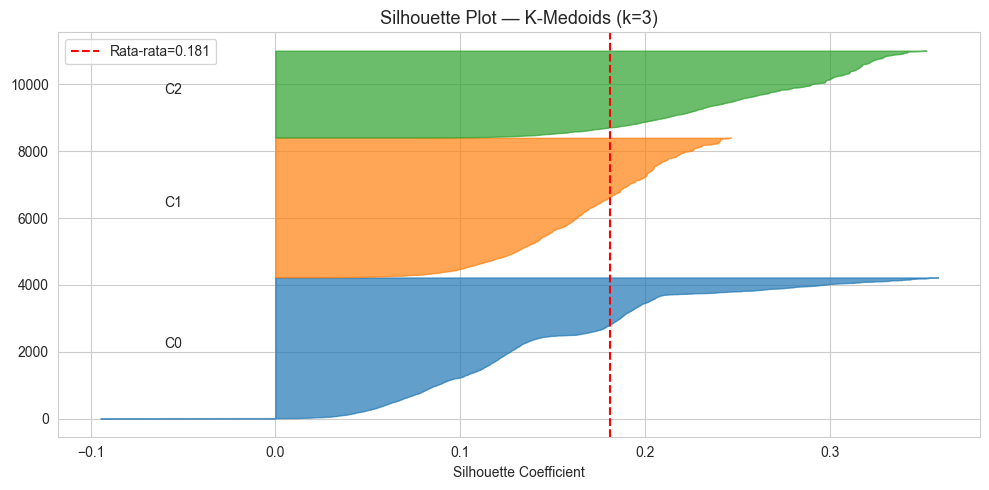

In [11]:
# Silhouette plot
sil_vals = silhouette_samples(X, km_labels)
fig, ax  = plt.subplots(figsize=(10, 5))
y_lower  = 10
for i in range(BEST_K):
    sil_i   = sorted(sil_vals[km_labels == i])
    y_upper = y_lower + len(sil_i)
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_i,
                     facecolor=COLORS[i], edgecolor=COLORS[i], alpha=0.7)
    ax.text(-0.06, y_lower + len(sil_i)*0.5, f'C{i}', fontsize=10)
    y_lower = y_upper + 10
avg = silhouette_score(X, km_labels)
ax.axvline(avg, color='red', ls='--', label=f'Rata-rata={avg:.3f}')
ax.set_title(f'Silhouette Plot — K-Medoids (k={BEST_K})')
ax.set_xlabel('Silhouette Coefficient')
ax.legend()
plt.tight_layout()
plt.show()

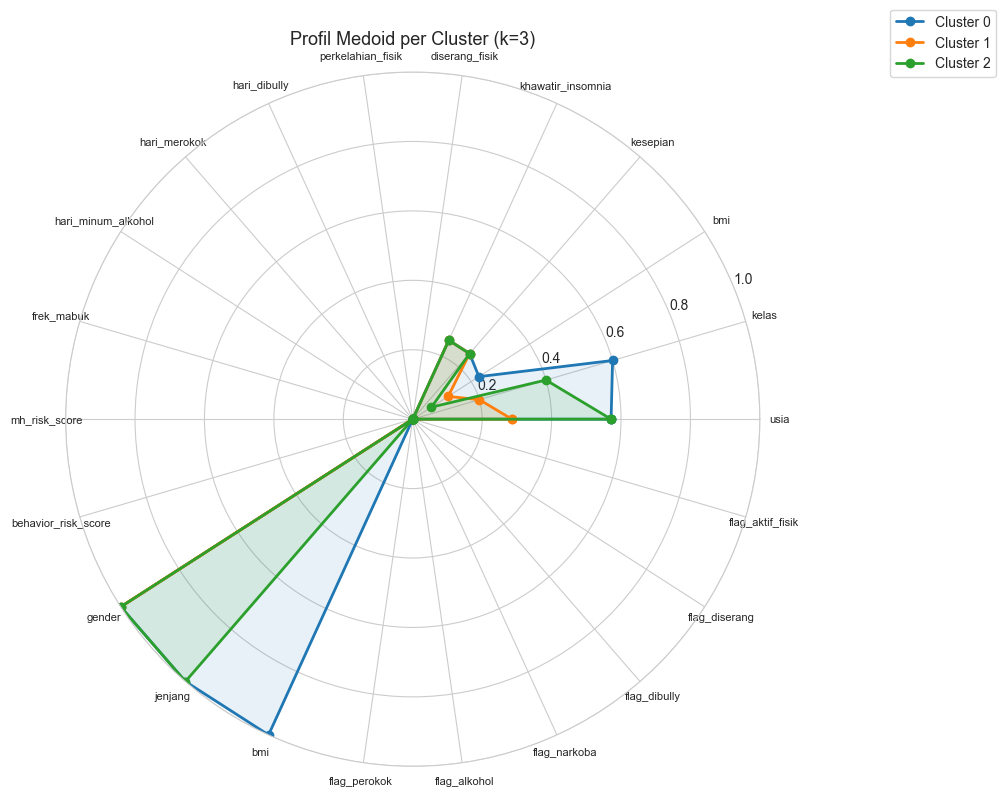

In [12]:
# Radar chart profil medoid
angles = np.linspace(0, 2*np.pi, len(feature_cols), endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw=dict(polar=True))
for i in range(BEST_K):
    vals = X[km_model.medoid_indices_[i]].tolist() + [X[km_model.medoid_indices_[i]][0]]
    ax.plot(angles, vals, 'o-', lw=2, color=COLORS[i], label=f'Cluster {i}')
    ax.fill(angles, vals, alpha=0.1, color=COLORS[i])
ax.set_xticks(angles[:-1])
ax.set_xticklabels([c.replace('_norm','').replace('_bin','').replace('_encoded','')
                    for c in feature_cols], size=8)
ax.set_ylim(0, 1)
ax.set_title(f'Profil Medoid per Cluster (k={BEST_K})', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1))
plt.tight_layout()
plt.show()

---
## 5. Hierarchical Clustering

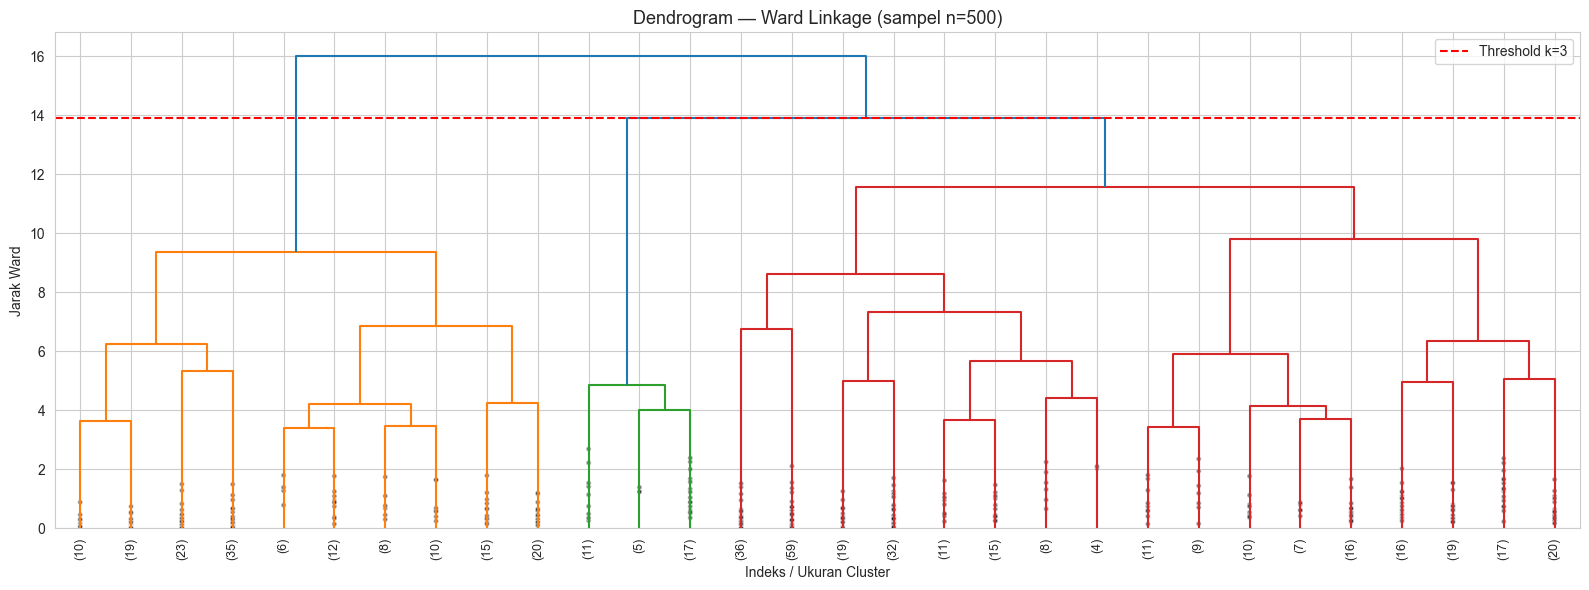

In [13]:
# Dendrogram (sampel 500)
np.random.seed(RS)
idx_s  = np.random.choice(len(X), 500, replace=False)
Z      = linkage(X[idx_s], method='ward')

fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=9,
           show_contracted=True, color_threshold=Z[-BEST_K+1, 2])
ax.axhline(Z[-BEST_K+1, 2], color='red', ls='--', lw=1.5,
           label=f'Threshold k={BEST_K}')
ax.set_title(f'Dendrogram — Ward Linkage (sampel n=500)')
ax.set_xlabel('Indeks / Ukuran Cluster')
ax.set_ylabel('Jarak Ward')
ax.legend()
plt.tight_layout()
plt.show()

In [14]:
# Bandingkan 3 linkage
hc_results = {}
print(f'{"Linkage":>10}  {"Silhouette":>12}  {"DB":>8}  {"Ukuran cluster"}')
print('-' * 55)
for method in ['ward', 'complete', 'average']:
    hc     = AgglomerativeClustering(n_clusters=BEST_K, linkage=method)
    labels = hc.fit_predict(X)
    sil    = silhouette_score(X, labels)
    db     = davies_bouldin_score(X, labels)
    sizes  = pd.Series(labels).value_counts().sort_index().tolist()
    hc_results[method] = {'labels': labels, 'sil': sil, 'db': db}
    print(f'{method:>10}  {sil:>12.4f}  {db:>8.4f}  {sizes}')

best_link  = max(hc_results, key=lambda m: hc_results[m]['sil'])
hc_labels  = hc_results[best_link]['labels']
print(f'\nLinkage terbaik: {best_link}  (Silhouette={hc_results[best_link]["sil"]:.4f})')

   Linkage    Silhouette        DB  Ukuran cluster
-------------------------------------------------------
      ward        0.1463    2.2826  [5225, 774, 4978]
  complete        0.1557    1.9725  [2505, 8468, 4]
   average        0.3370    1.5612  [10952, 3, 22]

Linkage terbaik: average  (Silhouette=0.3370)


---
## 6. DBSCAN

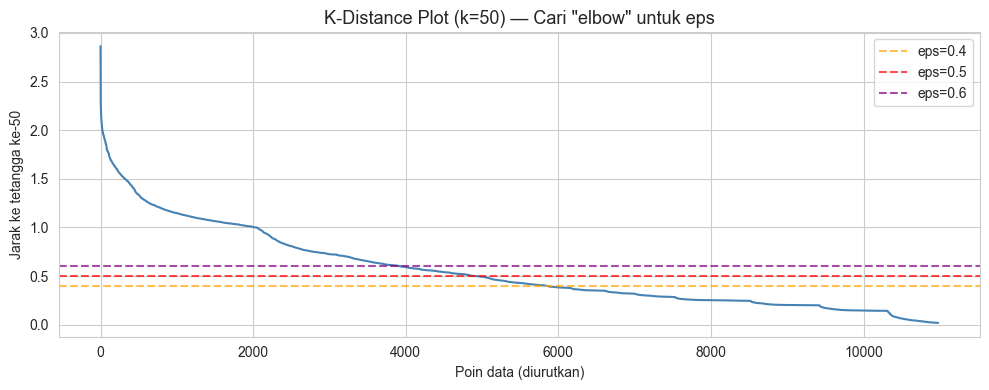

In [15]:
# K-Distance plot untuk pilih eps
nbrs   = NearestNeighbors(n_neighbors=50).fit(X)
dists, _ = nbrs.kneighbors(X)
k_dist = np.sort(dists[:, -1])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(k_dist, color='steelblue', lw=1.5)
for eps, col in [(0.4,'orange'), (0.5,'red'), (0.6,'purple')]:
    ax.axhline(eps, ls='--', color=col, alpha=0.7, label=f'eps={eps}')
ax.set_title('K-Distance Plot (k=50) — Cari "elbow" untuk eps')
ax.set_xlabel('Poin data (diurutkan)')
ax.set_ylabel('Jarak ke tetangga ke-50')
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
configs = [
    {'eps': 0.4, 'min_samples': 50},
    {'eps': 0.5, 'min_samples': 50},
    {'eps': 0.5, 'min_samples': 30},
    {'eps': 0.6, 'min_samples': 50},
]

print(f'{"eps":>6}  {"min_s":>6}  {"Clusters":>9}  {"Noise":>7}  {"Noise%":>7}  {"Silhouette":>11}')
print('-' * 55)
db_results = []
for cfg in configs:
    db  = DBSCAN(eps=cfg['eps'], min_samples=cfg['min_samples'])
    lbl = db.fit_predict(X)
    nc  = len(set(lbl)) - (1 if -1 in lbl else 0)
    nn  = (lbl == -1).sum()
    sil = silhouette_score(X[lbl!=-1], lbl[lbl!=-1]) if nc > 1 else np.nan
    db_results.append({**cfg, 'labels': lbl, 'n_clusters': nc, 'n_noise': nn,
                       'noise_pct': nn/len(lbl)*100, 'sil': sil})
    print(f'{cfg["eps"]:>6}  {cfg["min_samples"]:>6}  {nc:>9}  {nn:>7}  {nn/len(lbl)*100:>6.1f}%  '
          f'{sil:>11.4f}')

best_db   = max([r for r in db_results if not np.isnan(r['sil'])], key=lambda r: r['sil'])
db_labels = best_db['labels']
print(f'\nTerpilih: eps={best_db["eps"]}, min_samples={best_db["min_samples"]}')
print(f'Cluster={best_db["n_clusters"]}, Noise={best_db["n_noise"]} ({best_db["noise_pct"]:.1f}%)')

   eps   min_s   Clusters    Noise   Noise%   Silhouette
-------------------------------------------------------
   0.4      50         17     4576    41.7%       0.5158
   0.5      50         27     3379    30.8%       0.5056
   0.5      30         41     2547    23.2%       0.5019
   0.6      50         35     2611    23.8%       0.4957

Terpilih: eps=0.4, min_samples=50
Cluster=17, Noise=4576 (41.7%)


---
## 7. Perbandingan Ketiga Algoritma

In [17]:
mask_db = db_labels != -1
cmp = pd.DataFrame([
    {'Algoritma': f'K-Medoids (k={BEST_K})',
     'Clusters': BEST_K, 'Noise': 0,
     'Silhouette': round(silhouette_score(X, km_labels), 4),
     'Davies-Bouldin': round(davies_bouldin_score(X, km_labels), 4),
     'Calinski-H': round(calinski_harabasz_score(X, km_labels), 1)},
    {'Algoritma': f'Hierarchical-{best_link} (k={BEST_K})',
     'Clusters': BEST_K, 'Noise': 0,
     'Silhouette': round(hc_results[best_link]['sil'], 4),
     'Davies-Bouldin': round(hc_results[best_link]['db'], 4),
     'Calinski-H': round(calinski_harabasz_score(X, hc_labels), 1)},
    {'Algoritma': f'DBSCAN (eps={best_db["eps"]})',
     'Clusters': best_db['n_clusters'], 'Noise': best_db['n_noise'],
     'Silhouette': round(best_db['sil'], 4),
     'Davies-Bouldin': round(davies_bouldin_score(X[mask_db], db_labels[mask_db]), 4),
     'Calinski-H': round(calinski_harabasz_score(X[mask_db], db_labels[mask_db]), 1)},
]).set_index('Algoritma')
print('Perbandingan Kinerja:')
cmp

Perbandingan Kinerja:


,Clusters,Noise,Silhouette,Davies-Bouldin,Calinski-H
Algoritma,,,,,
K-Medoids (k=3),3,0,0.1811,1.7744,2171.8
Hierarchical-average (k=3),3,0,0.3370,1.5612,26.3
DBSCAN (eps=0.4),17,4576,0.5158,0.7886,2240.6


In [19]:
# Visualisasi 3 algoritma di PCA 2D
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (title, labels, noise_val) in zip(axes, [
    (f'K-Medoids (k={BEST_K})',           km_labels,  None),
    (f'Hierarchical-{best_link} (k={BEST_K})', hc_labels, None),
    (f'DBSCAN (eps={best_db["eps"]})',     db_labels,  -1),
]):
    cmap = {}; ci = 0
    for l in unique:
    # Tambahkan % len(COLORS) pada COLORS[ci]
    cmap[l] = 'lightgrey' if l == noise_val else COLORS[ci % len(COLORS)] 
    ci += (l != noise_val)
    ax.scatter(X_pca[:,0], X_pca[:,1],
               c=[cmap[l] for l in labels], alpha=0.4, s=5)
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    patches = [mpatches.Patch(color=cmap[l],
               label='Noise' if l == noise_val else f'Cluster {l}') for l in unique]
    ax.legend(handles=patches, fontsize=8)
plt.suptitle('Perbandingan Hasil Clustering (PCA 2D)', fontsize=13)
plt.tight_layout()
plt.show()

IndentationError: expected an indented block after 'for' statement on line 9 (2706522278.py, line 11)

---
## 8. Interpretasi Profil Cluster

Menggunakan **K-Medoids** sebagai model utama.

In [ ]:
df_out = df.copy()
df_out['cluster'] = km_labels

profile = df_out.groupby('cluster')[feature_cols].mean().round(3)
profile['n']          = df_out.groupby('cluster').size()
profile['%_total']    = (profile['n'] / len(df_out) * 100).round(1)
profile['%_suicidal'] = (df_out.groupby('cluster')['target'].mean() * 100).round(2)
profile

In [ ]:
# Heatmap profil cluster
fig, ax = plt.subplots(figsize=(15, 6))
sns.heatmap(profile[feature_cols].T, annot=True, fmt='.2f',
            cmap='YlOrRd', vmin=0, vmax=1,
            linewidths=0.4, ax=ax, annot_kws={'size': 8})
ax.set_title(f'Heatmap Profil Cluster — K-Medoids (k={BEST_K})\n(nilai = rata-rata fitur, skala 0–1)')
ax.set_xlabel('Cluster'); ax.set_ylabel('Fitur')
plt.tight_layout()
plt.show()

In [ ]:
# Grouped bar — fitur kunci
key_f = ['kesepian_norm','khawatir_insomnia_norm','hari_dibully_norm',
         'diserang_fisik_norm','flag_perokok_bin','flag_alkohol_bin',
         'flag_narkoba_bin','mh_risk_score_norm','flag_aktif_fisik_bin']
key_f = [c for c in key_f if c in feature_cols]
key_l = ['Kesepian','Khawatir','Di-bully','Diserang',
         'Perokok','Alkohol','Narkoba','Risk Score','Aktif Fisik'][:len(key_f)]

x = np.arange(len(key_f)); w = 0.8 / BEST_K
fig, ax = plt.subplots(figsize=(15, 5))
for i in range(BEST_K):
    offset = (i - BEST_K/2 + 0.5) * w
    ax.bar(x + offset, profile.loc[i, key_f], w,
           label=f'Cluster {i}', color=COLORS[i], edgecolor='white', alpha=0.85)
ax.set_xticks(x); ax.set_xticklabels(key_l, rotation=15)
ax.set_ylabel('Rata-rata (0–1)')
ax.set_title(f'Fitur Kunci per Cluster (K-Medoids, k={BEST_K})')
ax.legend()
plt.tight_layout()
plt.show()

print('\nPrevalensi Suicidal Ideation per Cluster:')
for c in range(BEST_K):
    n   = (km_labels == c).sum()
    pct = df_out[df_out['cluster']==c]['target'].mean()*100
    print(f'  Cluster {c}: {n:,} pelajar ({n/len(df_out)*100:.1f}%), suicidal={pct:.2f}%')

---
## 9. Deteksi Outlier

In [ ]:
# DBSCAN noise
db_noise = db_labels == -1
print(f'DBSCAN noise : {db_noise.sum()} ({db_noise.sum()/len(df)*100:.1f}%)')

# LOF
lof        = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
lof_pred   = lof.fit_predict(X)
lof_scores = -lof.negative_outlier_factor_
lof_mask   = lof_pred == -1
print(f'LOF (5%)     : {lof_mask.sum()} ({lof_mask.sum()/len(df)*100:.1f}%)')

# Isolation Forest
iso      = IsolationForest(contamination=0.05, random_state=RS, n_estimators=100)
iso_pred = iso.fit_predict(X)
iso_mask = iso_pred == -1
print(f'Isolation F  : {iso_mask.sum()} ({iso_mask.sum()/len(df)*100:.1f}%)')

# Konsensus
consensus = lof_mask & iso_mask
print(f'Konsensus    : {consensus.sum()} ({consensus.sum()/len(df)*100:.1f}%)')

In [ ]:
# Visualisasi outlier
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
titles = ['DBSCAN Noise', 'LOF (5%)', 'Konsensus LOF+IF']
masks  = [db_noise, lof_mask, consensus]
for ax, title, mask in zip(axes, titles, masks):
    ax.scatter(X_pca[~mask,0], X_pca[~mask,1], c='#A8D8A8', alpha=0.3, s=5, label='Normal')
    ax.scatter(X_pca[mask,0],  X_pca[mask,1],  c='#FF4444', alpha=0.8, s=20,
               label=f'Outlier (n={mask.sum()})')
    ax.set_title(title); ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
    ax.legend(fontsize=8)
plt.suptitle('Deteksi Outlier (PCA 2D)', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
# Profil outlier vs normal
overall_suc = df['target'].mean() * 100
rows = []
for name, mask in [('DBSCAN', db_noise), ('LOF', lof_mask),
                   ('Isolation Forest', iso_mask), ('Konsensus', consensus)]:
    suc = df['target'][mask].mean()*100 if mask.sum() > 0 else 0
    rows.append({'Metode': name, 'n Outlier': mask.sum(),
                 '% Total': round(mask.sum()/len(df)*100, 2),
                 '% Suicidal di Outlier': round(suc, 2)})
out_cmp = pd.DataFrame(rows).set_index('Metode')
print(f'Prevalensi suicidal keseluruhan: {overall_suc:.2f}%')
out_cmp

---
## 10. Visualisasi t-SNE

In [ ]:
print('Menghitung t-SNE (sampel 3000)...')
np.random.seed(RS)
idx_t  = np.random.choice(len(X), 3000, replace=False)
X_tsne = TSNE(n_components=2, perplexity=40, n_iter=1000,
              random_state=RS).fit_transform(X[idx_t])

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Warna cluster
for c in range(BEST_K):
    m = km_labels[idx_t] == c
    axes[0].scatter(X_tsne[m,0], X_tsne[m,1], c=[COLORS[c]],
                    alpha=0.5, s=10, label=f'Cluster {c}')
axes[0].set_title(f't-SNE — K-Medoids (k={BEST_K})')
axes[0].set_xlabel('t-SNE 1'); axes[0].set_ylabel('t-SNE 2')
axes[0].legend()

# Warna suicidal
y_s = y_true[idx_t]
axes[1].scatter(X_tsne[y_s==0,0], X_tsne[y_s==0,1],
                c='#A8D8A8', alpha=0.3, s=8, label='Tidak (suicidal)')
axes[1].scatter(X_tsne[y_s==1,0], X_tsne[y_s==1,1],
                c='#FF4444', alpha=0.9, s=25, label='Ya (suicidal)', zorder=5)
axes[1].set_title('t-SNE — Suicidal Ideation')
axes[1].set_xlabel('t-SNE 1'); axes[1].set_ylabel('t-SNE 2')
axes[1].legend()

plt.suptitle('t-SNE Visualization (n=3000)', fontsize=13)
plt.tight_layout()
plt.show()
print('Selesai!')

---
## 11. Kesimpulan & Export

In [ ]:
# Export hasil
df_out['cluster_hc']      = hc_labels
df_out['cluster_dbscan']  = db_labels
df_out['outlier_lof']     = lof_mask.astype(int)
df_out['outlier_iso']     = iso_mask.astype(int)
df_out['outlier_konsensus'] = consensus.astype(int)
df_out.to_csv('gshs2015_clustered_results.csv', index=False)
print('Disimpan: gshs2015_clustered_results.csv')

# Ringkasan
print()
print('=' * 55)
print('RINGKASAN HASIL CLUSTERING')
print('=' * 55)
print(f'Dataset      : {len(df):,} pelajar, {len(feature_cols)} fitur')
print(f'k dipilih    : {BEST_K}')
print()
print('Evaluasi:')
print(cmp.to_string())
print()
print('Profil Cluster (K-Medoids):')
for c in range(BEST_K):
    n   = (km_labels==c).sum()
    suc = df_out[df_out['cluster']==c]['target'].mean()*100
    print(f'  Cluster {c}: n={n:,} ({n/len(df_out)*100:.1f}%), suicidal={suc:.2f}%')
print()
print('Deteksi Outlier:')
print(out_cmp.to_string())
print('=' * 55)